<a href="https://colab.research.google.com/github/adilkamal2478/Adil_Pandas_Data_Preprocessing/blob/main/Session_29_my_task_solution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Perform EDA on below insurance dataset

Link: https://www.kaggle.com/datasets/thedevastator/insurance-claim-analysis-demographic-and-health

Perform All steps of EDA and document conclusions and then perform feature engineering.

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
df = pd.read_csv("/content/drive/MyDrive/Data_processing/Session_29/insurance_data.csv")

In [5]:
df.set_index('index' , inplace = True)

In [6]:
df.head()

,PatientID,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
index,,,,,,,,,,
0,1,39.0,male,23.2,91,Yes,0,No,southeast,1121.87
1,2,24.0,male,30.1,87,No,0,No,southeast,1131.51
2,3,NaN,male,33.3,82,Yes,0,No,southeast,1135.94
3,4,NaN,male,33.7,80,No,0,No,northwest,1136.40
4,5,NaN,male,34.1,100,No,0,No,northwest,1137.01


### Column Types

- **Numerical** - PatientID , age , bmi , bloodpressure ,  claim
- **Categorical** - gender , diabetic , smoker , region , children

### Steps of doing Univariate Analysis on Numerical columns

- **Descriptive Statistics**: Compute basic summary statistics for the column, such as mean, median, mode, standard deviation, range, and quartiles. These statistics give a general understanding of the distribution of the data and can help identify skewness or outliers.

- **Visualizations**: Create visualizations to explore the distribution of the data. Some common visualizations for numerical data include `histograms`, `box plots`, and `density plots`(u can say kde). These visualizations provide a visual representation of the distribution of the data and can help identify skewness an outliers.

- **Identifying Outliers**: Identify and examine any outliers in the data. Outliers can be identified using visualizations. It is important to determine whether the outliers are due to measurement errors, data entry errors, or legitimate differences in the data, and to decide whether to include or exclude them from the analysis.

- **Skewness**: Check for skewness in the data and consider transforming the data or using robust statistical methods that are less sensitive to skewness, if necessary.

- **Conclusion**: Summarize the findings of the EDA and make decisions about how to proceed with further analysis.


# Age

**Conclusion**

- 5 missing values
- almost perfectly symmetric.

In [7]:
df['age'].describe()

,age
count,1335.000000
mean,38.078652
std,11.102924
min,18.000000
25%,29.000000
50%,38.000000
75%,47.000000
max,60.000000


<Axes: ylabel='Frequency'>

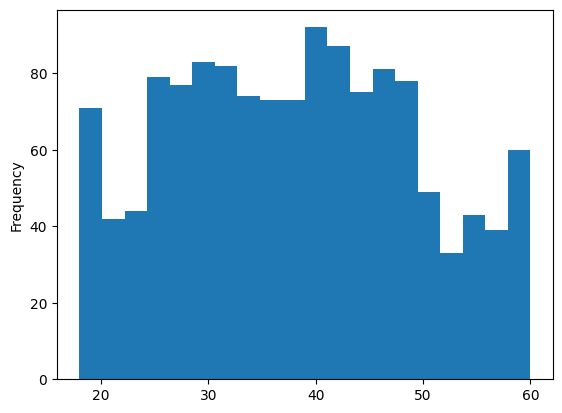

In [8]:
df['age'].plot(kind='hist' , bins = 20)

<Axes: >

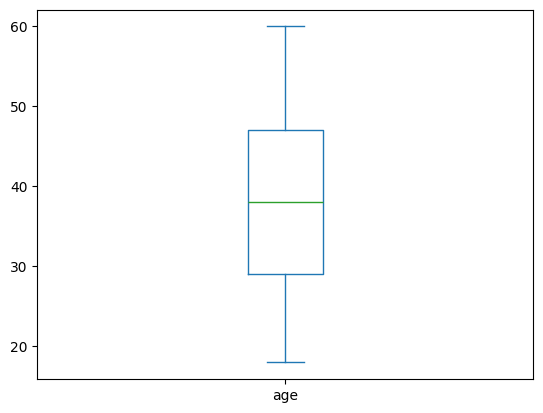

In [9]:
df['age'].plot(kind='box')
# no outliers

<Axes: ylabel='Density'>

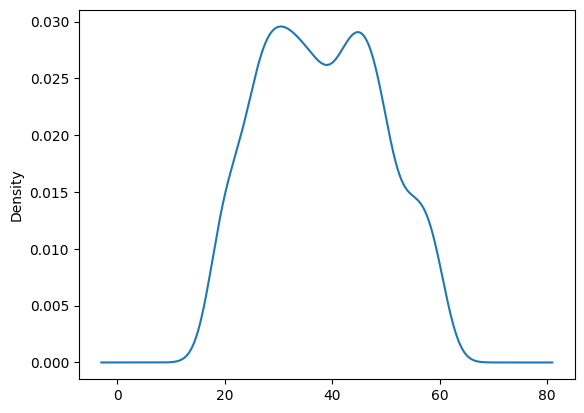

In [10]:
df['age'].plot(kind='kde')

In [11]:
df['age'].skew()

np.float64(0.11361133741072633)

In [12]:
df['age'].isnull().sum()

np.int64(5)

#bmi

- Underweight (< 18.5)

- Normal Weight (18.5 – 24.9)

- Overweight (25.0 – 29.9)

- Class 1 Obesity (30.0 – 34.9)

- Class 2 Obesity (35.0 – 39.9)

- Class 3 Obesity (40.0 to 60.0+)

**Conclusion**

- more than 80% of people are overwigtht or having obesity
- approx 93 people have class 3 obesity

In [13]:
df['bmi'].describe()

,bmi
count,1340.000000
mean,30.668955
std,6.106735
min,16.000000
25%,26.275000
50%,30.400000
75%,34.700000
max,53.100000


<Axes: ylabel='Frequency'>

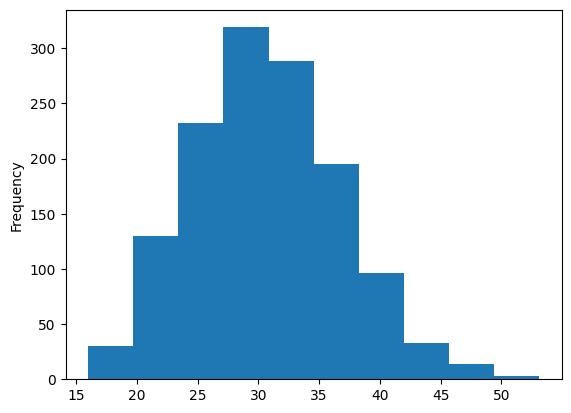

In [14]:
df['bmi'].plot(kind = 'hist')

<Axes: >

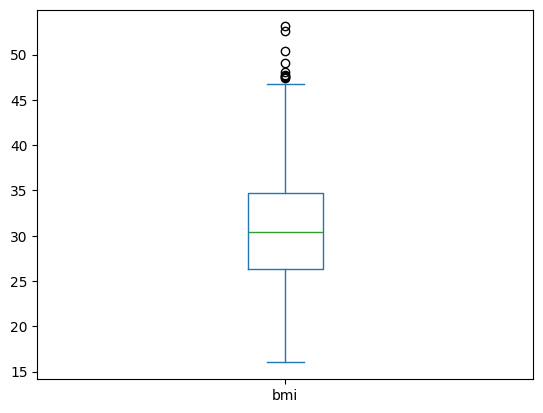

In [15]:
df['bmi'].plot(kind = 'box')

# some outliers

<Axes: ylabel='Density'>

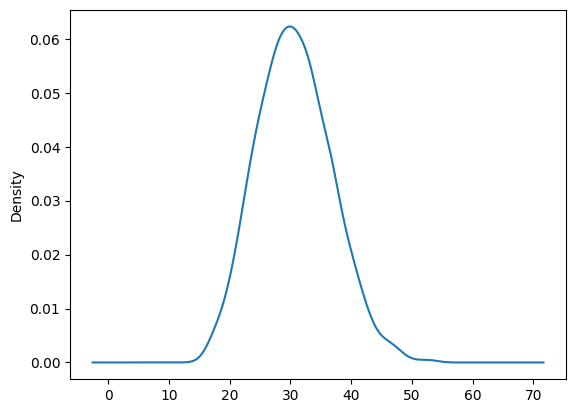

In [16]:
df['bmi'].plot(kind = 'kde')

In [17]:
df['bmi'].skew()

np.float64(0.28597245020808587)

In [18]:
df['bmi'].isnull().sum()

np.int64(0)

In [19]:
len(df[df['bmi'] >= 25]) / len(df)

0.8186567164179105

# Bloodpressure

- Below 90 → Hypotension (low blood pressure)

- 90–119 → Normal range

- 120–129 → Elevated (borderline high)

- 130–139 → Hypertension Stage 1

- 140–159 → Hypertension Stage 2

- 160+ → Severe hypertension

**Conclusion**

- +1.4 skewness , positively skewd , means mean will be higher than median , means few values that has higher values which inreases the mean

In [20]:
df['bloodpressure']

,bloodpressure
index,
0,91
1,87
2,82
3,80
4,100
...,...
1335,88
1336,120
1337,91


In [21]:
df['bloodpressure'].describe()

,bloodpressure
count,1340.000000
mean,94.157463
std,11.434712
min,80.000000
25%,86.000000
50%,92.000000
75%,99.000000
max,140.000000


In [22]:
df['bloodpressure'].median()

92.0

In [23]:
df['bloodpressure'].value_counts()

,count
bloodpressure,
91,62
80,59
88,58
81,58
89,58
...,...
138,1
116,1
134,1


<Axes: ylabel='Frequency'>

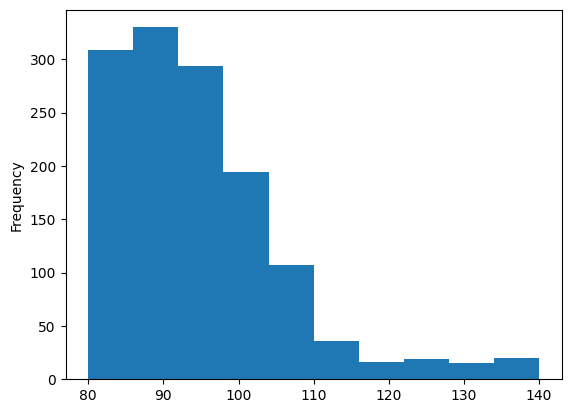

In [24]:
df['bloodpressure'].plot(kind = 'hist')

<Axes: >

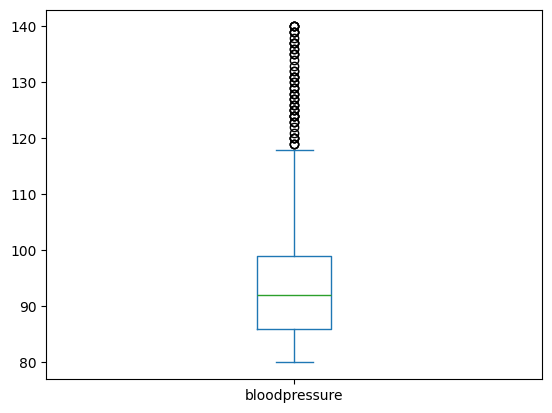

In [25]:
df['bloodpressure'].plot(kind = 'box')

In [26]:
df[df['bloodpressure'] > 110]

,PatientID,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
index,,,,,,,,,,
1147,1148,29.0,female,32.7,128,Yes,2,No,northwest,26018.95
1148,1149,32.0,male,26.7,115,Yes,1,Yes,northwest,26109.33
1150,1151,55.0,female,27.1,135,No,1,No,southwest,26140.36
1152,1153,38.0,female,35.9,128,No,1,No,northeast,26392.26
1153,1154,43.0,male,36.8,126,No,2,No,northwest,26467.10
...,...,...,...,...,...,...,...,...,...,...
1330,1331,25.0,female,38.1,111,No,0,Yes,southeast,48885.14
1332,1333,26.0,male,37.0,120,No,2,Yes,southeast,49577.66
1333,1334,44.0,male,36.4,127,No,1,Yes,southwest,51194.56


<Axes: ylabel='Density'>

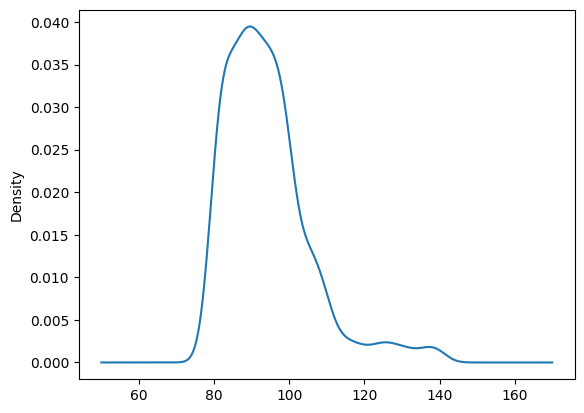

In [27]:
df['bloodpressure'].plot(kind = 'kde')

In [28]:
df['bloodpressure'].skew()

np.float64(1.4835342102293079)

In [29]:
df['bloodpressure'].isnull().sum()

np.int64(0)

# claim

**Conclusion**

- +1.5 skewness , positively skewd , means mean will be higher than median , means few values that has higher values which inreases the mean

In [30]:
df['claim'].describe()

,claim
count,1340.000000
mean,13252.745642
std,12109.609288
min,1121.870000
25%,4719.685000
50%,9369.615000
75%,16604.305000
max,63770.430000


In [31]:
df['claim'].median()

9369.615

<Axes: ylabel='Frequency'>

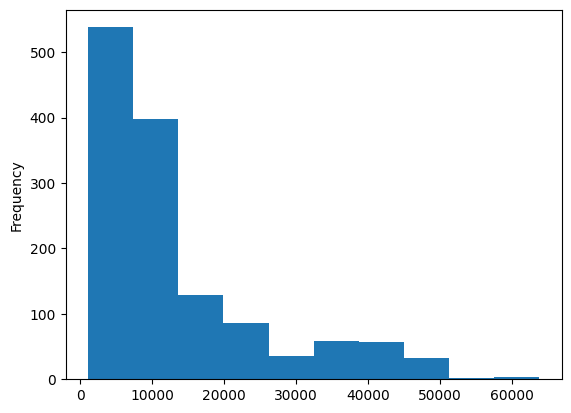

In [32]:
df['claim'].plot(kind = 'hist')

<Axes: >

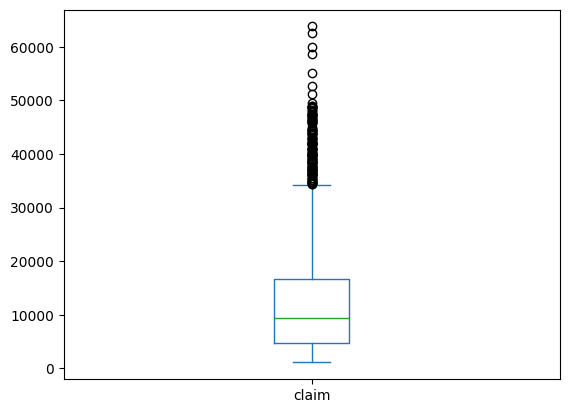

In [33]:
df['claim'].plot(kind = 'box')

# too much outliers

<Axes: ylabel='Density'>

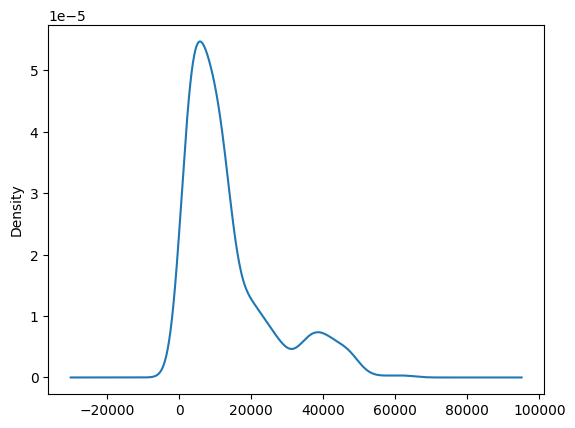

In [34]:
df['claim'].plot(kind = 'kde')

In [35]:
df['claim'].skew()

np.float64(1.5167468509489237)

In [36]:
df['claim'].isnull().sum()

np.int64(0)

In [37]:
df[df['claim'] > 30000]

,PatientID,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
index,,,,,,,,,,
1178,1179,27.0,male,37.7,95,No,3,No,northwest,30063.58
1179,1180,19.0,male,24.7,97,Yes,1,No,northwest,30166.62
1180,1181,39.0,male,29.8,110,No,3,Yes,northeast,30184.94
1181,1182,32.0,male,28.6,132,No,0,No,northeast,30260.00
1182,1183,36.0,male,25.4,84,No,2,No,northwest,30284.64
...,...,...,...,...,...,...,...,...,...,...
1335,1336,44.0,female,35.5,88,Yes,0,Yes,northwest,55135.40
1336,1337,59.0,female,38.1,120,No,1,Yes,northeast,58571.07
1337,1338,30.0,male,34.5,91,Yes,3,Yes,northwest,60021.40


### Steps of doing Univariate Analysis on Categorical columns

**Descriptive Statistics**: Compute the frequency distribution of the categories in the column. This will give a general understanding of the distribution of the categories and their relative frequencies.

**Visualizations**: Create visualizations to explore the distribution of the categories. Some common visualizations for categorical data include `count plots` and `pie charts`. These visualizations provide a visual representation of the distribution of the categories and can help identify any patterns or anomalies in the data.

**Missing Values**: Check for missing values in the data and decide how to handle them. Missing values can be imputed or excluded from the analysis, depending on the research question and the data set.

**Conclusion**: Summarize the findings of the EDA and make decisions about how to proceed with further analysis.

# Categorical - gender , diabetic , smoker , region , children

# gender

conclusion
- almost equal distribution

In [38]:
df['gender'].value_counts()

,count
gender,
male,678
female,662


<Axes: xlabel='gender'>

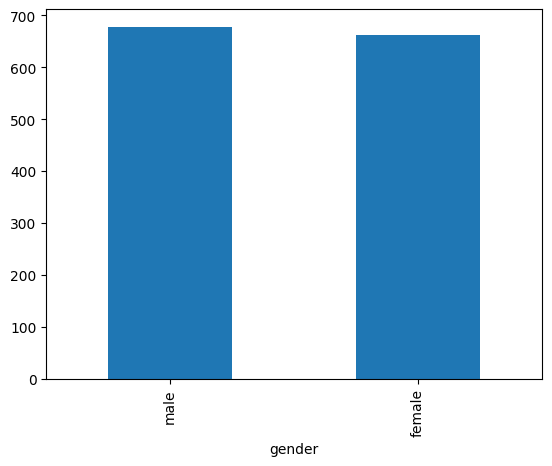

In [39]:
df['gender'].value_counts().plot(kind = 'bar')

<Axes: ylabel='count'>

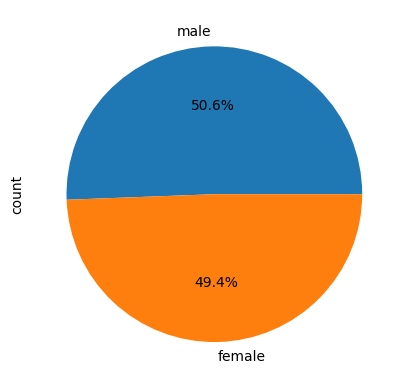

In [40]:
df['gender'].value_counts().plot(kind = 'pie' , autopct = '%0.1f%%')

In [41]:
df['gender'].isnull().sum()

np.int64(0)

# diabetic

conclusion
- almost equal distribution

In [42]:
df['diabetic'].value_counts()

,count
diabetic,
No,698
Yes,642


<Axes: xlabel='diabetic'>

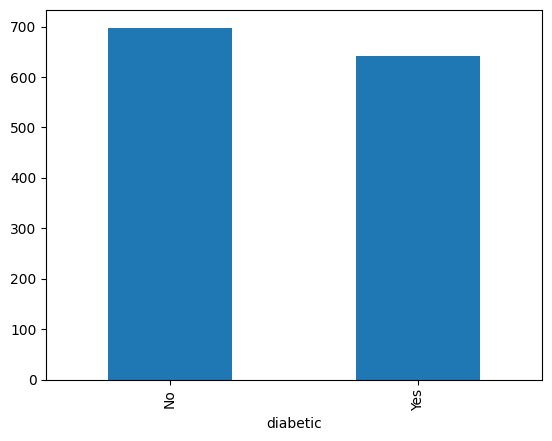

In [43]:
df['diabetic'].value_counts().plot(kind = 'bar')

<Axes: ylabel='count'>

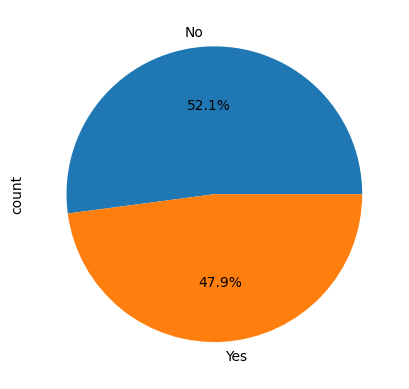

In [44]:
df['diabetic'].value_counts().plot(kind = 'pie' , autopct = '%0.1f%%')

In [45]:
df['diabetic'].isnull().sum()

np.int64(0)

# smoker

conclusion
- almost 80% of them are non smoker

In [46]:
df['smoker'].value_counts()

,count
smoker,
No,1066
Yes,274


<Axes: xlabel='smoker'>

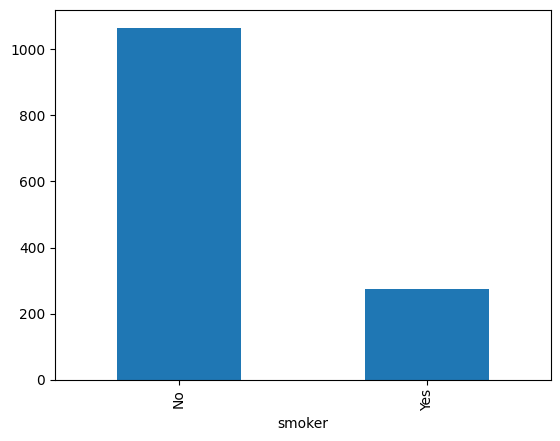

In [47]:
df['smoker'].value_counts().plot(kind = 'bar')

<Axes: ylabel='count'>

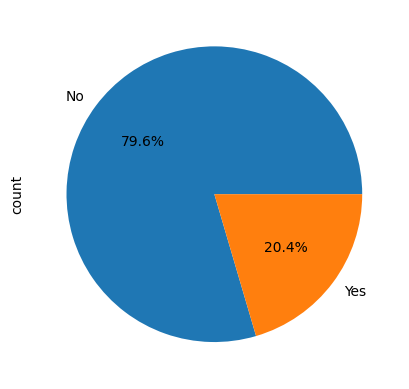

In [48]:
df['smoker'].value_counts().plot(kind = 'pie' , autopct = '%0.1f%%')

In [49]:
df['smoker'].isnull().sum()

np.int64(0)

# region

conclusion
- 33% are from southeast, highest
- 17% are from northeast, lowest
- `3 missing values`

In [50]:
df['region'].value_counts()

,count
region,
southeast,443
northwest,349
southwest,314
northeast,231


<Axes: xlabel='region'>

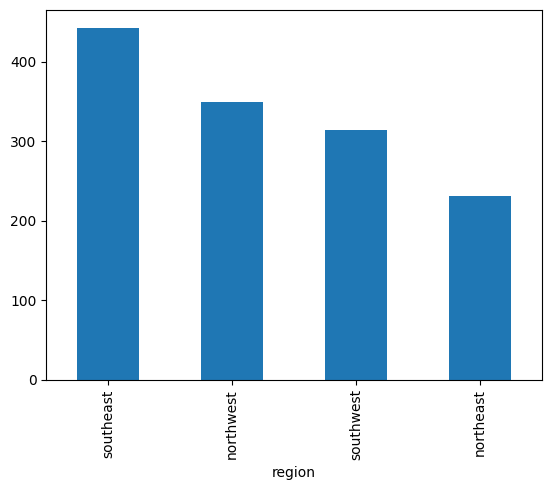

In [51]:
df['region'].value_counts().plot(kind = 'bar')

<Axes: ylabel='count'>

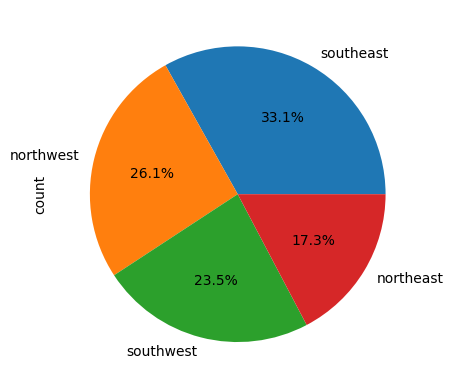

In [52]:
df['region'].value_counts().plot(kind = 'pie' , autopct = '%0.1f%%')

In [53]:
df['region'].isnull().sum()

np.int64(3)

# children

conclusion
- almost 80% of people have 2 or less child

In [54]:
df['children'].value_counts()

,count
children,
0,576
1,324
2,240
3,157
4,25
5,18


<Axes: xlabel='children'>

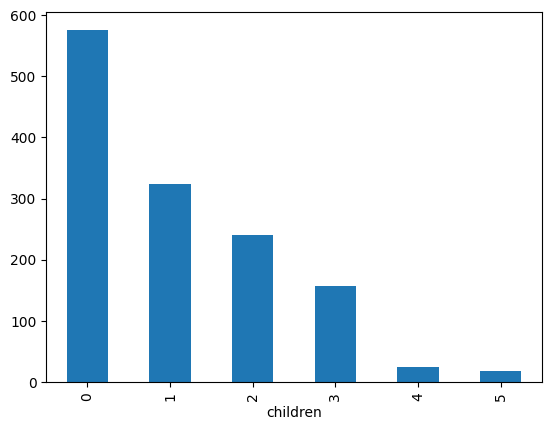

In [55]:
df['children'].value_counts().plot(kind = 'bar')

<Axes: ylabel='count'>

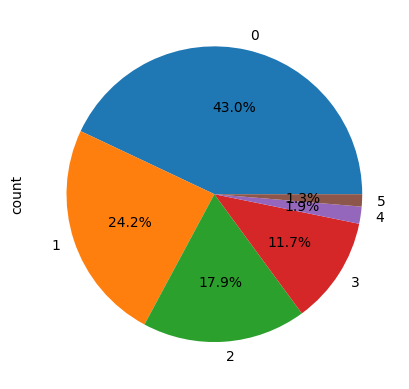

In [56]:
df['children'].value_counts().plot(kind = 'pie' , autopct = '%0.1f%%')

In [57]:
df['children'].isnull().sum()

np.int64(0)

### Steps of doing Bivariate Analysis

- Select 2 cols
- Understand type of relationship
    1. **Numerical - Numerical**<br>
        a. You can plot graphs like scatterplot(regression plots), 2D histplot, 2D KDEplots<br>
        b. Check correlation coefficent to check linear relationship
    2. **Numerical - Categorical** - create visualizations that compare the distribution of the numerical data across different categories of the categorical data.<br>
        a. You can plot graphs like barplot, boxplot, kdeplot violinplot even scatterplots<br>
    3. **Categorical - Categorical**<br>
        a. You can create cross-tabulations or contingency tables that show the distribution of values in one categorical column, grouped by the values in the other categorical column.<br>
        b. You can plots like heatmap, stacked barplots, treemaps
        
- Write your conclusions

### Column Types

- **Numerical** - PatientID , age , bmi , bloodpressure ,  claim
- **Categorical** - gender , diabetic , smoker , region , children

In [58]:
df

,PatientID,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
index,,,,,,,,,,
0,1,39.0,male,23.2,91,Yes,0,No,southeast,1121.87
1,2,24.0,male,30.1,87,No,0,No,southeast,1131.51
2,3,NaN,male,33.3,82,Yes,0,No,southeast,1135.94
3,4,NaN,male,33.7,80,No,0,No,northwest,1136.40
4,5,NaN,male,34.1,100,No,0,No,northwest,1137.01
...,...,...,...,...,...,...,...,...,...,...
1335,1336,44.0,female,35.5,88,Yes,0,Yes,northwest,55135.40
1336,1337,59.0,female,38.1,120,No,1,Yes,northeast,58571.07
1337,1338,30.0,male,34.5,91,Yes,3,Yes,northwest,60021.40


# Gender vs Diabitic (categorical - categorical)

In [59]:
pd.crosstab(df['gender'] , df['diabetic'] )

diabetic,No,Yes
gender,,
female,339,323
male,359,319


In [60]:
pd.crosstab(df['gender'] , df['diabetic'] , normalize = 'columns')*100

diabetic,No,Yes
gender,,
female,48.567335,50.311526
male,51.432665,49.688474


<Axes: xlabel='diabetic', ylabel='gender'>

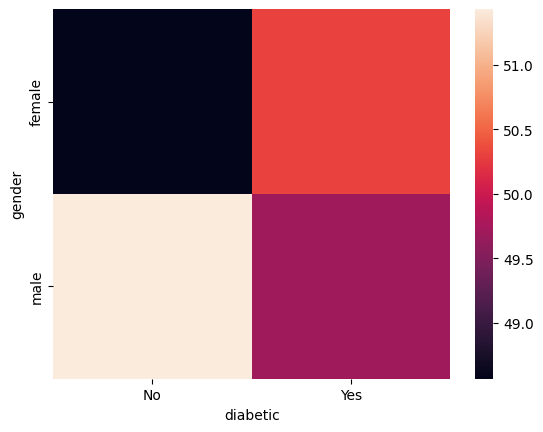

In [61]:
sns.heatmap(pd.crosstab(df['gender'] , df['diabetic'] , normalize = 'columns')*100)

## Gender vs Smoker (categorical - categorical)

In [62]:
pd.crosstab(df['gender'] , df['smoker'] )

smoker,No,Yes
gender,,
female,547,115
male,519,159


In [63]:
pd.crosstab(df['gender'] , df['smoker'] , normalize = 'index')*100

smoker,No,Yes
gender,,
female,82.628399,17.371601
male,76.548673,23.451327


<Axes: xlabel='smoker', ylabel='gender'>

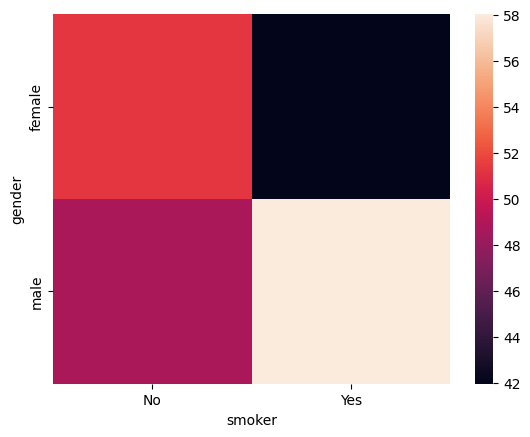

In [64]:
sns.heatmap(pd.crosstab(df['gender'] , df['smoker'] , normalize = 'columns')*100)

## Gender vs children (categorical - categorical)

In [65]:
pd.crosstab(df['gender'] , df['children'] , normalize = 'columns')*100

children,0,1,2,3,4,5
gender,,,,,,
female,50.173611,48.765432,49.583333,49.044586,44.0,44.444444
male,49.826389,51.234568,50.416667,50.955414,56.0,55.555556


<Axes: xlabel='children', ylabel='gender'>

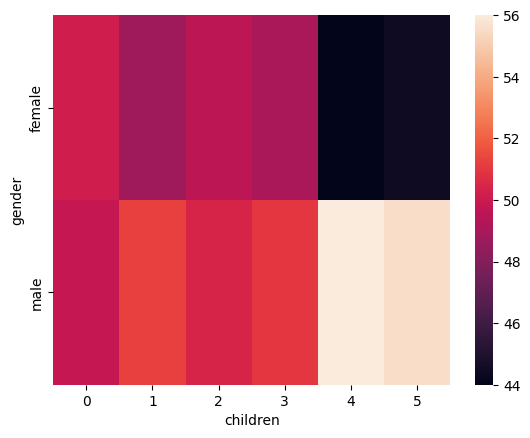

In [66]:
sns.heatmap(pd.crosstab(df['gender'] , df['children'] , normalize = 'columns')*100)

## Gender vs Region (categorical - categorical)

In [67]:
pd.crosstab(df['gender'] , df['region'] )

region,northeast,northwest,southeast,southwest
gender,,,,
female,112,164,224,162
male,119,185,219,152


In [68]:
pd.crosstab(df['gender'] , df['region'] , normalize = 'columns')*100

region,northeast,northwest,southeast,southwest
gender,,,,
female,48.484848,46.991404,50.564334,51.592357
male,51.515152,53.008596,49.435666,48.407643


<Axes: xlabel='region', ylabel='gender'>

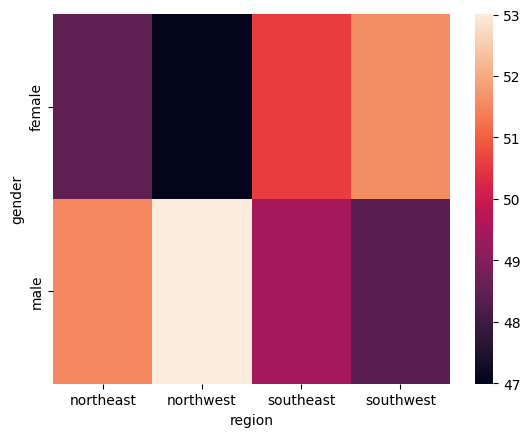

In [69]:
sns.heatmap(pd.crosstab(df['gender'] , df['region'] , normalize = 'columns')*100)

## Diabitic vs Smoker (categorical - categorical)

In [70]:
pd.crosstab(df['diabetic'] , df['smoker'] )

smoker,No,Yes
diabetic,,
No,560,138
Yes,506,136


In [71]:
pd.crosstab(df['diabetic'] , df['smoker'], normalize = 'index')*100

smoker,No,Yes
diabetic,,
No,80.229226,19.770774
Yes,78.816199,21.183801


<Axes: xlabel='smoker', ylabel='diabetic'>

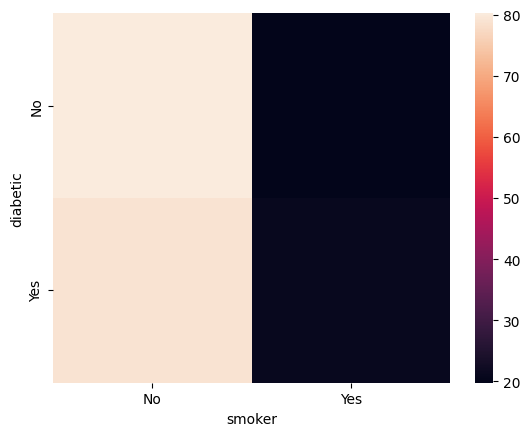

In [72]:
sns.heatmap(pd.crosstab(df['diabetic'] , df['smoker'], normalize = 'index')*100)

## Diabetic vs Region (categorical - categorical)

In [73]:
pd.crosstab(df['diabetic'] , df['region'])

region,northeast,northwest,southeast,southwest
diabetic,,,,
No,110,192,225,170
Yes,121,157,218,144


In [74]:
pd.crosstab(df['diabetic'] , df['region'], normalize = 'columns') *100

region,northeast,northwest,southeast,southwest
diabetic,,,,
No,47.619048,55.014327,50.790068,54.140127
Yes,52.380952,44.985673,49.209932,45.859873


<Axes: xlabel='region', ylabel='diabetic'>

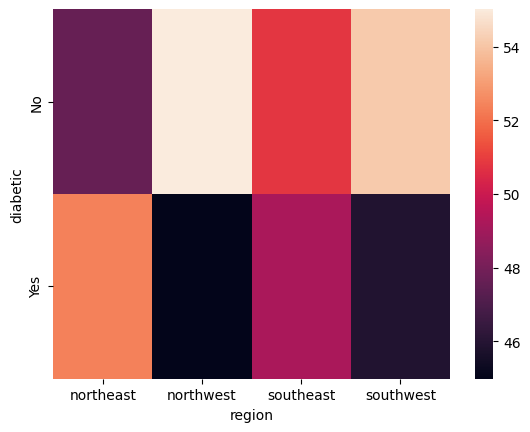

In [75]:
sns.heatmap(pd.crosstab(df['diabetic'] , df['region'], normalize = 'columns') *100)

## Diabetic vs Children (categorical - categorical)

In [76]:
pd.crosstab(df['diabetic'] , df['children'])

children,0,1,2,3,4,5
diabetic,,,,,,
No,292,179,120,83,13,11
Yes,284,145,120,74,12,7


In [77]:
pd.crosstab(df['diabetic'] , df['children'], normalize = 'columns') *100

children,0,1,2,3,4,5
diabetic,,,,,,
No,50.694444,55.246914,50.0,52.866242,52.0,61.111111
Yes,49.305556,44.753086,50.0,47.133758,48.0,38.888889


<Axes: xlabel='children', ylabel='diabetic'>

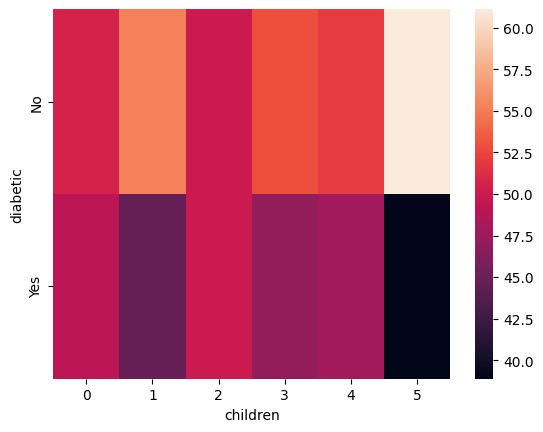

In [78]:
sns.heatmap(pd.crosstab(df['diabetic'] , df['children'], normalize = 'columns') *100)

## Smoker vs Region (categorical - categorical)

In [79]:
pd.crosstab(df['smoker'] , df['region'])

region,northeast,northwest,southeast,southwest
smoker,,,,
No,164,291,352,256
Yes,67,58,91,58


In [80]:
pd.crosstab(df['smoker'] , df['region'] , normalize='columns')*100

region,northeast,northwest,southeast,southwest
smoker,,,,
No,70.995671,83.381089,79.458239,81.528662
Yes,29.004329,16.618911,20.541761,18.471338


<Axes: xlabel='region', ylabel='smoker'>

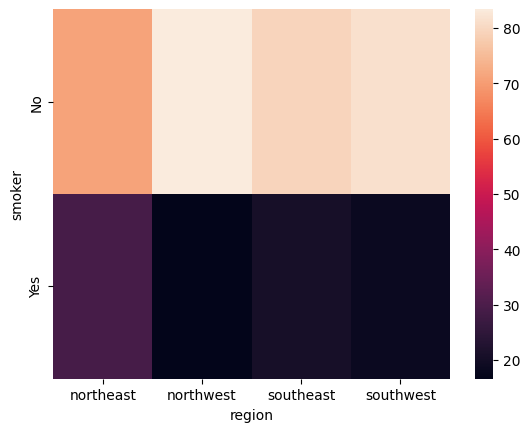

In [81]:
sns.heatmap(pd.crosstab(df['smoker'] , df['region'] , normalize='columns')*100)

## Smoker vs Children (categorical - categorical)

In [82]:
pd.crosstab(df['smoker'] , df['children'])

children,0,1,2,3,4,5
smoker,,,,,,
No,461,263,185,118,22,17
Yes,115,61,55,39,3,1


In [83]:
pd.crosstab(df['smoker'] , df['children'] , normalize='columns')*100

children,0,1,2,3,4,5
smoker,,,,,,
No,80.034722,81.17284,77.083333,75.159236,88.0,94.444444
Yes,19.965278,18.82716,22.916667,24.840764,12.0,5.555556


<Axes: xlabel='children', ylabel='smoker'>

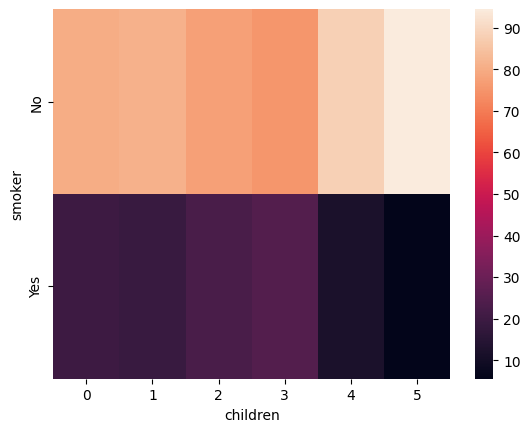

In [84]:
sns.heatmap(pd.crosstab(df['smoker'] , df['children'] , normalize='columns')*100)

## Region vs Children (categorical - categorical)

In [85]:
pd.crosstab(df['region'] , df['children'] , normalize = 'columns')*100

children,0,1,2,3,4,5
region,,,,,,
northeast,18.324607,17.592593,15.416667,15.923567,24.0,5.555556
northwest,26.876091,23.456790,27.500000,29.299363,24.0,5.555556
southeast,32.460733,35.185185,33.333333,31.210191,24.0,44.444444
southwest,22.338569,23.765432,23.750000,23.566879,28.0,44.444444


<Axes: xlabel='children', ylabel='region'>

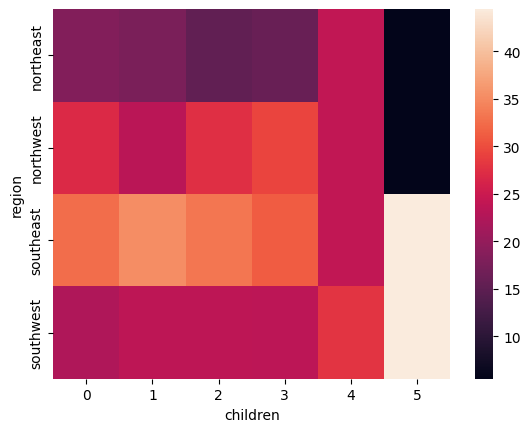

In [86]:
sns.heatmap(pd.crosstab(df['region'] , df['children'] , normalize = 'columns')*100)

### Column Types

- **Numerical** - PatientID , age , bmi , bloodpressure ,  claim
- **Categorical** - gender , diabetic , smoker , region , children

##Numerical - Numerical

Age vs Bmi

In [87]:
df[['age' , 'bmi']].describe()

,age,bmi
count,1335.000000,1340.000000
mean,38.078652,30.668955
std,11.102924,6.106735
min,18.000000,16.000000
25%,29.000000,26.275000
50%,38.000000,30.400000
75%,47.000000,34.700000
max,60.000000,53.100000


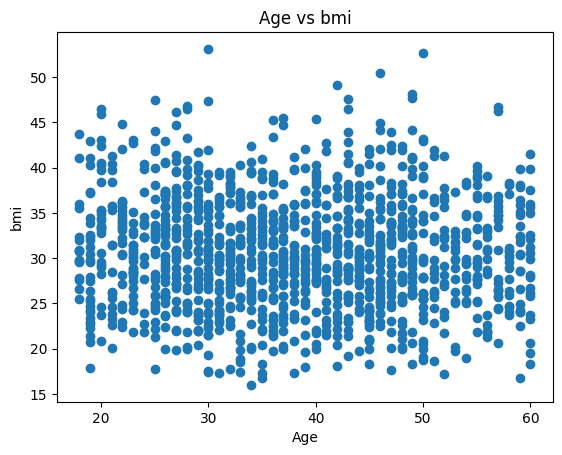

In [88]:
plt.scatter(df['age'], df['bmi'])
plt.xlabel('Age')
plt.ylabel('bmi')
plt.title('Age vs bmi')
plt.show()

In [89]:
df[['age','bmi']].corr(method='pearson')

,age,bmi
age,1.000000,-0.041955
bmi,-0.041955,1.000000


<Axes: xlabel='age', ylabel='bmi'>

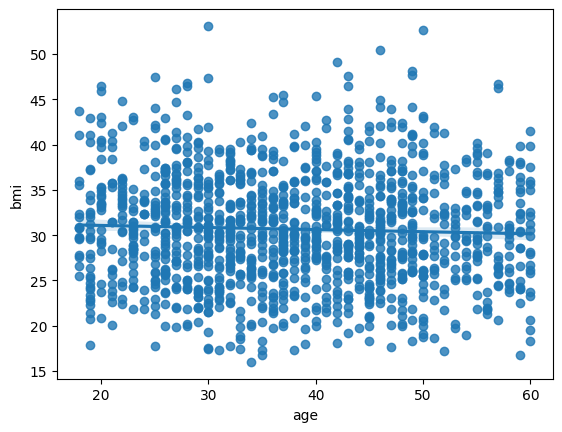

In [90]:
sns.regplot(x='age', y='bmi', data=df)

## Age vs Bloodpressure

In [91]:
df[['age' , 'bloodpressure']].describe()

,age,bloodpressure
count,1335.000000,1340.000000
mean,38.078652,94.157463
std,11.102924,11.434712
min,18.000000,80.000000
25%,29.000000,86.000000
50%,38.000000,92.000000
75%,47.000000,99.000000
max,60.000000,140.000000


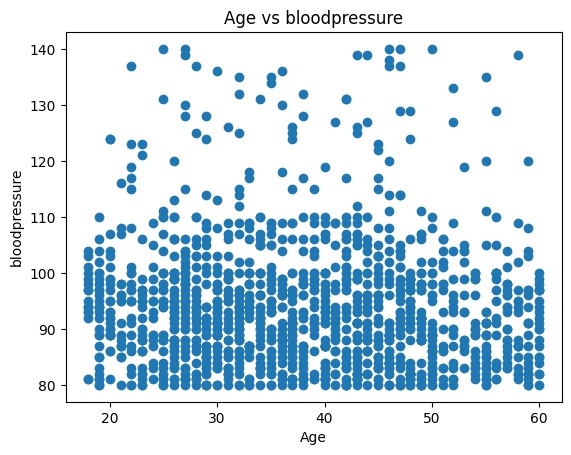

In [92]:
plt.scatter(df['age'], df['bloodpressure'])
plt.xlabel('Age')
plt.ylabel('bloodpressure')
plt.title('Age vs bloodpressure')
plt.show()

In [93]:
df[['age','bloodpressure']].corr(method='pearson')

,age,bloodpressure
age,1.000000,-0.060325
bloodpressure,-0.060325,1.000000


<Axes: xlabel='age', ylabel='bloodpressure'>

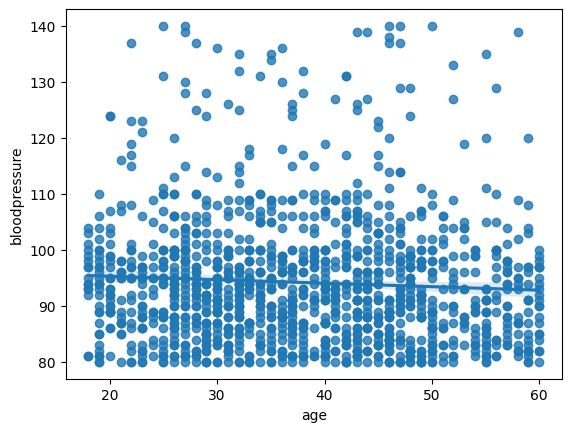

In [94]:
sns.regplot(x='age', y='bloodpressure', data=df)

## Age vs claim

In [95]:
df[['age' , 'claim']].describe()

,age,claim
count,1335.000000,1340.000000
mean,38.078652,13252.745642
std,11.102924,12109.609288
min,18.000000,1121.870000
25%,29.000000,4719.685000
50%,38.000000,9369.615000
75%,47.000000,16604.305000
max,60.000000,63770.430000


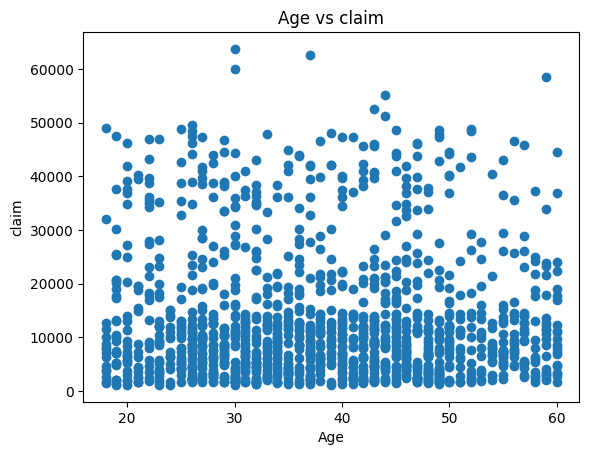

In [96]:
plt.scatter(df['age'], df['claim'])
plt.xlabel('Age')
plt.ylabel('claim')
plt.title('Age vs claim')
plt.show()

In [97]:
df[['age','claim']].corr(method='pearson')

,age,claim
age,1.000000,-0.027909
claim,-0.027909,1.000000


<Axes: xlabel='age', ylabel='claim'>

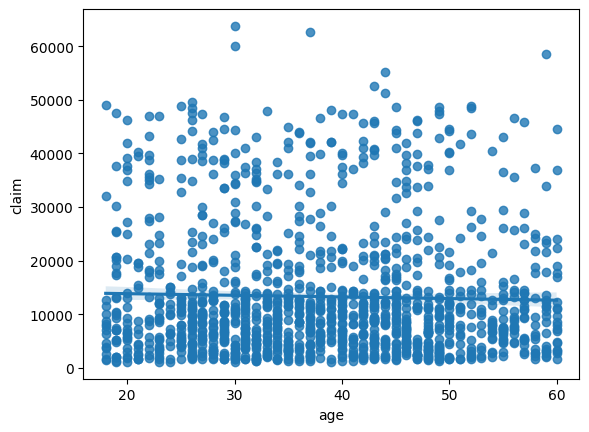

In [98]:
sns.regplot(x='age', y='claim', data=df)

## bmi vs bloodpressure

In [99]:
df[['bmi' , 'bloodpressure']].describe()

,bmi,bloodpressure
count,1340.000000,1340.000000
mean,30.668955,94.157463
std,6.106735,11.434712
min,16.000000,80.000000
25%,26.275000,86.000000
50%,30.400000,92.000000
75%,34.700000,99.000000
max,53.100000,140.000000


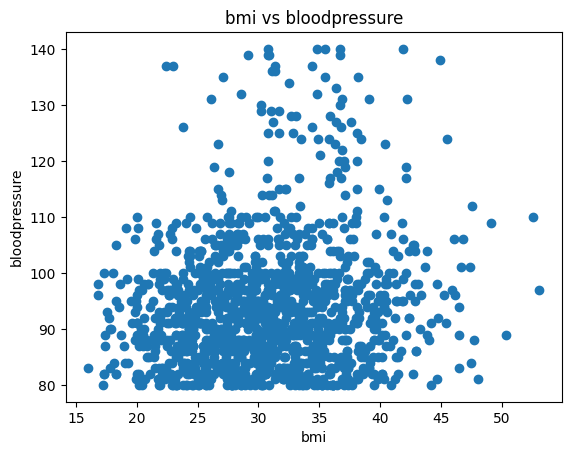

In [100]:
plt.scatter(df['bmi'], df['bloodpressure'])
plt.xlabel('bmi')
plt.ylabel('bloodpressure')
plt.title('bmi vs bloodpressure')
plt.show()

In [101]:
df[['bmi','bloodpressure']].corr(method='pearson')

,bmi,bloodpressure
bmi,1.000000,0.143544
bloodpressure,0.143544,1.000000


<Axes: xlabel='bmi', ylabel='bloodpressure'>

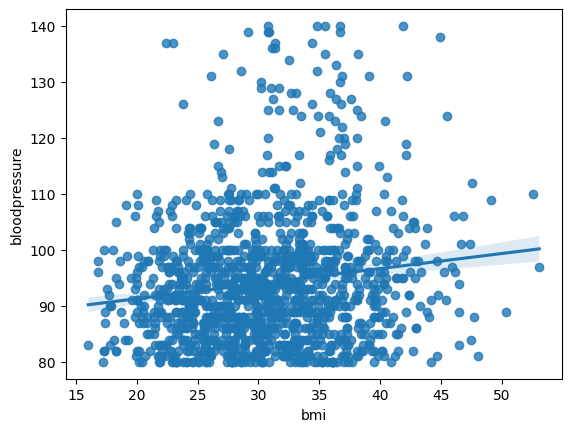

In [102]:
sns.regplot(x='bmi', y='bloodpressure', data=df)

## bmi vs claim

In [103]:
df[['bmi' , 'claim']].describe()

,bmi,claim
count,1340.000000,1340.000000
mean,30.668955,13252.745642
std,6.106735,12109.609288
min,16.000000,1121.870000
25%,26.275000,4719.685000
50%,30.400000,9369.615000
75%,34.700000,16604.305000
max,53.100000,63770.430000


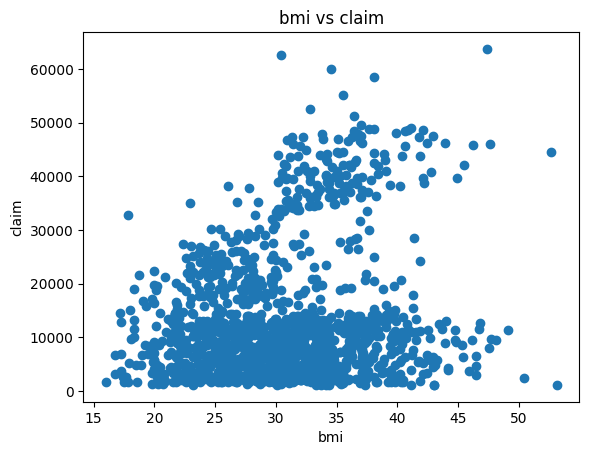

In [104]:
plt.scatter(df['bmi'], df['claim'])
plt.xlabel('bmi')
plt.ylabel('claim')
plt.title('bmi vs claim')
plt.show()

In [105]:
df[['bmi','claim']].corr(method='pearson')

,bmi,claim
bmi,1.000000,0.197401
claim,0.197401,1.000000


<Axes: xlabel='bmi', ylabel='claim'>

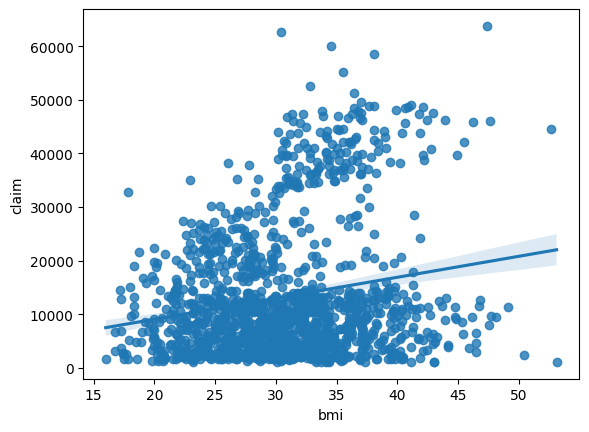

In [106]:
sns.regplot(x='bmi', y='claim', data=df)

## Bp vs claim

In [107]:
df[['bloodpressure' , 'claim']].describe()

,bloodpressure,claim
count,1340.000000,1340.000000
mean,94.157463,13252.745642
std,11.434712,12109.609288
min,80.000000,1121.870000
25%,86.000000,4719.685000
50%,92.000000,9369.615000
75%,99.000000,16604.305000
max,140.000000,63770.430000


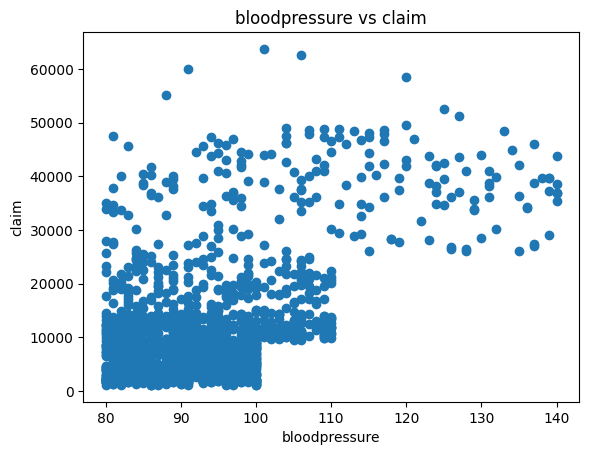

In [108]:
plt.scatter(df['bloodpressure'], df['claim'])
plt.xlabel('bloodpressure')
plt.ylabel('claim')
plt.title('bloodpressure vs claim')
plt.show()

In [109]:
df[['bloodpressure','claim']].corr(method='pearson')

,bloodpressure,claim
bloodpressure,1.000000,0.531341
claim,0.531341,1.000000


<Axes: xlabel='bloodpressure', ylabel='claim'>

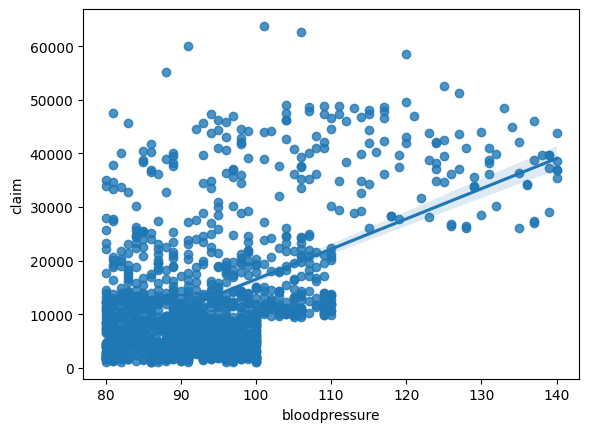

In [110]:
sns.regplot(x='bloodpressure', y='claim', data=df)

In [111]:
df

,PatientID,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
index,,,,,,,,,,
0,1,39.0,male,23.2,91,Yes,0,No,southeast,1121.87
1,2,24.0,male,30.1,87,No,0,No,southeast,1131.51
2,3,NaN,male,33.3,82,Yes,0,No,southeast,1135.94
3,4,NaN,male,33.7,80,No,0,No,northwest,1136.40
4,5,NaN,male,34.1,100,No,0,No,northwest,1137.01
...,...,...,...,...,...,...,...,...,...,...
1335,1336,44.0,female,35.5,88,Yes,0,Yes,northwest,55135.40
1336,1337,59.0,female,38.1,120,No,1,Yes,northeast,58571.07
1337,1338,30.0,male,34.5,91,Yes,3,Yes,northwest,60021.40


# Doing some feature engineering

In [ ]:
# on column bmi

# Underweight: Below 18.5
# Healthy/Normal Weight: 18.5 to 24.9
# Overweight: 25.0 to 29.9
# Obesity Class I: 30.0 to 34.9
# Obesity Class II: 35.0 to 39.9
# Obesity Class III (Severe/Extreme Obesity): 40.0 and above

In [112]:
df.head()

,PatientID,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
index,,,,,,,,,,
0,1,39.0,male,23.2,91,Yes,0,No,southeast,1121.87
1,2,24.0,male,30.1,87,No,0,No,southeast,1131.51
2,3,NaN,male,33.3,82,Yes,0,No,southeast,1135.94
3,4,NaN,male,33.7,80,No,0,No,northwest,1136.40
4,5,NaN,male,34.1,100,No,0,No,northwest,1137.01


In [121]:
# bmi_classification

def bmi_range(x):
  if x < 18.5:
    return 'Underweight'
  elif x >= 18.5 and x <= 24.9:
    return 'Healthy'
  elif x >= 25 and x <= 29.9:
    return 'Overweight'
  elif x >= 30 and x <= 34.9:
    return 'Obesity Class I'
  elif x >= 35 and x <= 39.9:
    return 'Obesity Class II'
  elif x >= 40 :
    return 'Obesity Class III'



In [126]:
bmi_range(80)

'Obesity Class III'

In [127]:
df['bmi_classification'] = df['bmi'].apply(bmi_range)

In [128]:
df.head()

,PatientID,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim,bmi_classification
index,,,,,,,,,,,
0,1,39.0,male,23.2,91,Yes,0,No,southeast,1121.87,Healthy
1,2,24.0,male,30.1,87,No,0,No,southeast,1131.51,Obesity Class I
2,3,NaN,male,33.3,82,Yes,0,No,southeast,1135.94,Obesity Class I
3,4,NaN,male,33.7,80,No,0,No,northwest,1136.40,Obesity Class I
4,5,NaN,male,34.1,100,No,0,No,northwest,1137.01,Obesity Class I


In [129]:
# for blood pressure column

In [ ]:
# Typical systolic blood pressure categories:

# < 90 → Hypotension (Low BP)

# 90–119 → Normal

# 120–129 → Elevated

# 130–139 → Hypertension Stage 1

# 140–159 → Hypertension Stage 2

# ≥ 160 → Severe Hypertension


# our data set contains only one value , it is probabily the systolic one

In [131]:
def bp_range(x):
  if x < 90:
    return 'Low BP'
  elif x >= 90 and x <= 119:
    return 'Normal'
  elif x >= 120 and x <= 129:
    return 'Elevated'
  elif x >= 130 and x <= 139:
    return 'Hypertension Stage 1'
  elif x >= 140 and x <= 159:
    return 'Hypertension Stage 2'
  elif x >= 160 :
    return 'Severe Hypertension'

In [135]:
bp_range(120)

'Elevated'

In [136]:
df['bp_classification'] = df['bloodpressure'].apply(bp_range)

In [137]:
df.head()

,PatientID,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim,bmi_classification,bp_classification
index,,,,,,,,,,,,
0,1,39.0,male,23.2,91,Yes,0,No,southeast,1121.87,Healthy,Normal
1,2,24.0,male,30.1,87,No,0,No,southeast,1131.51,Obesity Class I,Low BP
2,3,NaN,male,33.3,82,Yes,0,No,southeast,1135.94,Obesity Class I,Low BP
3,4,NaN,male,33.7,80,No,0,No,northwest,1136.40,Obesity Class I,Low BP
4,5,NaN,male,34.1,100,No,0,No,northwest,1137.01,Obesity Class I,Normal
